In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Data Cleaning

# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\abhay\AppData\Local\Temp\ipykernel_8960\457876299.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

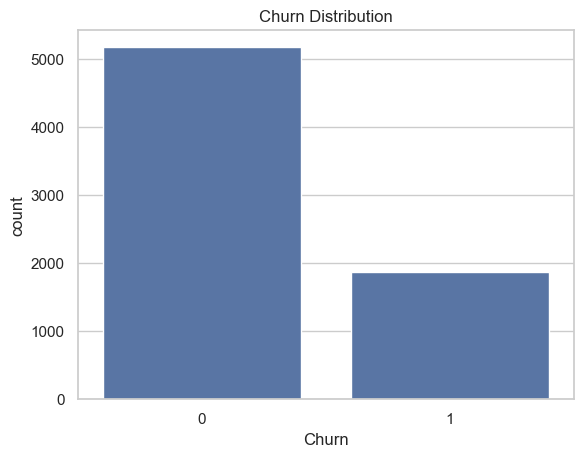

In [13]:
# Exploratory Data Analysis (EDA)
# Churn Distribution

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

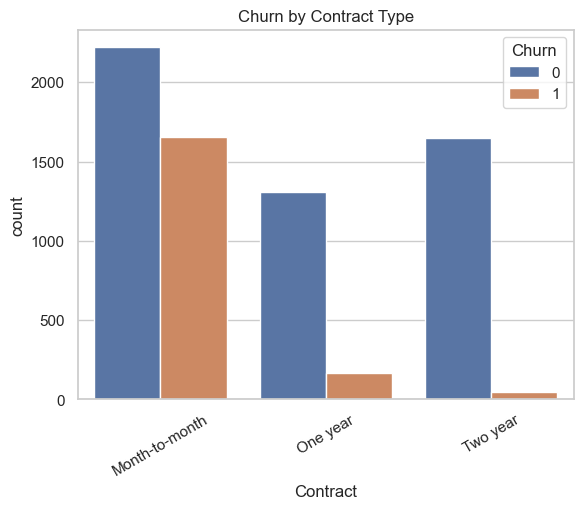

In [14]:
# Churn by Contract 
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=30)
plt.show()

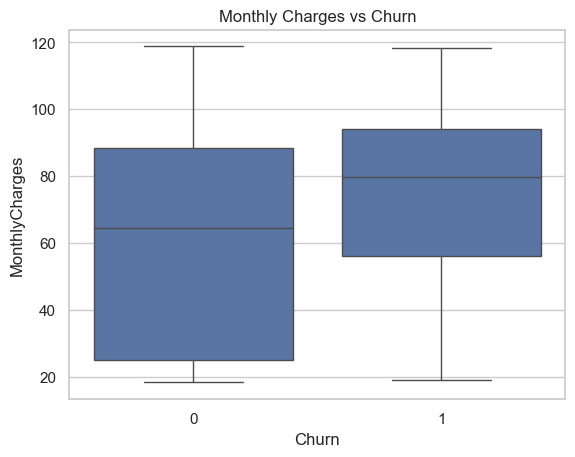

In [15]:
# Monthly Charges by Churn

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

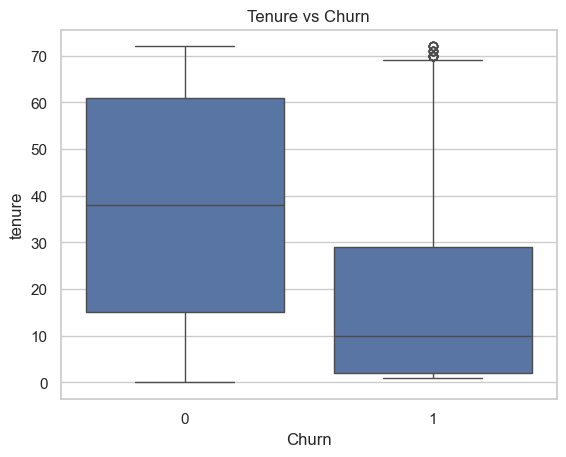

In [16]:
# Tenure by Churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

In [17]:
# 5. Feature Engineering
# Create tenure group
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,60,100],
                           labels=['0-1yr','1-2yr','2-4yr','4-5yr','5+yr'])

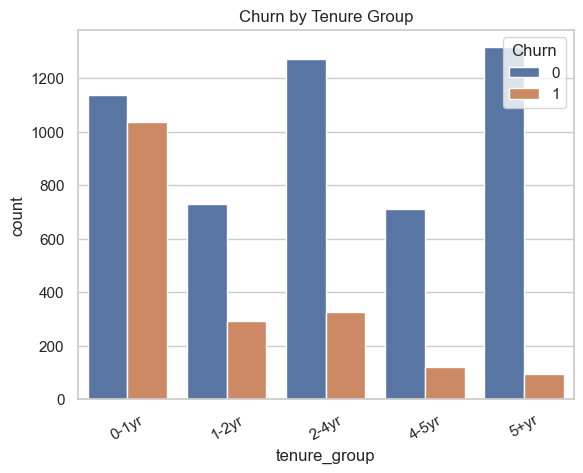

In [18]:
sns.countplot(x='tenure_group', hue='Churn', data=df)
plt.title("Churn by Tenure Group")
plt.xticks(rotation=30)
plt.show()

In [22]:
# Key Insights
# 1.Churn rate
churn_rate = df['Churn'].mean()
print("Churn Rate:", churn_rate)

Churn Rate: 0.2653698707936959


In [23]:
# 2.Contract vs churn percentage
contract_churn = df.groupby('Contract')['Churn'].mean()
print(contract_churn)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


In [24]:
# 3.Internet service churn
internet_churn = df.groupby('InternetService')['Churn'].mean()
print(internet_churn)

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64


In [27]:
## Conclusion

"""
- Customers with month-to-month contracts have the highest churn.
- Higher monthly charges lead to increased churn probability.
- Customers with shorter tenure are more likely to churn.
- Fiber optic users show higher churn compared to DSL.

Business Recommendation:
- Offer discounts for long-term contracts
- Target high-risk customers with retention campaigns
- Improve service quality for fiber customers
"""

'\n- Customers with month-to-month contracts have the highest churn.\n- Higher monthly charges lead to increased churn probability.\n- Customers with shorter tenure are more likely to churn.\n- Fiber optic users show higher churn compared to DSL.\n\nBusiness Recommendation:\n- Offer discounts for long-term contracts\n- Target high-risk customers with retention campaigns\n- Improve service quality for fiber customers\n'

In [29]:
# STEP 1: Install required libraries (run once)
!pip install mysql-connector-python sqlalchemy pandas

# STEP 2: Import libraries
import pandas as pd
from sqlalchemy import create_engine

# STEP 3: Load your cleaned dataset
# (Replace with your file or skip if df already exists)
# df = pd.read_csv("cleaned_data.csv")

# STEP 4: MySQL connection details (EDIT THESE)
username = "root"
password = "Abhay123"
host = "localhost"
database = "churn_case"

# STEP 5: Create connection engine
engine = create_engine(f"mysql+mysqlconnector://{username}:{password}@{host}/{database}")

# STEP 6: Upload DataFrame to MySQL
table_name = "customer_churn"

df.to_sql(
    name=table_name,
    con=engine,
    if_exists='replace',   # use 'append' if you don't want to overwrite
    index=False
)

print(f"✅ Data successfully inserted into table '{table_name}'")

# STEP 7: Verify (read from MySQL)
df_mysql = pd.read_sql(f"SELECT * FROM {table_name}", con=engine)

print("✅ Data from MySQL:")
print(df_mysql.head())

Access is denied.


✅ Data successfully inserted into table 'customer_churn'
✅ Data from MySQL:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... TechSupport  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...         Yes   
4                No     Fiber optic             No  ...          No   

  StreamingTV St